# Dataset Creation

## Import Libraries

In [33]:
import pandas as pd
import emoji
import time
import html
pd.options.display.max_colwidth = None

## Raw Datasets

In [34]:
# Read data
try:
    df1 = pd.read_csv('Data-Raw/df1_english.csv', sep=',')
    df2 = pd.read_csv('Data-Raw/df2_english.csv', sep=',')
    df3 = pd.read_csv('Data-Raw/df3_english.csv', sep=',')
    df4 = pd.read_csv('Data-Raw/df4_english.tsv', sep='\t')
    df5 = pd.read_csv('Data-Raw/df5_english.csv', sep=',')
    df6 = pd.read_csv('Data-Raw/df6_english.csv', sep=',')
    df7 = pd.read_csv('Data-Raw/df7_english.csv', sep=',')
    df8 = pd.read_csv('Data-Raw/df8_english.csv', sep=',')
    df9 = pd.read_csv('Data-Raw/df9_english.csv', sep=',')
    df10 = pd.read_excel('Data-Raw/Dataset 1.xlsx')
    df11 = pd.read_excel('Data-Raw/Dataset 2.xlsx')
except Exception as e:
    print(f"Error: {e}")

In [35]:
# Check columns
print("Columns for df1:")
print(df1.columns)
print("\n-----------------------------------")
print("\nColumns for df2:")
print(df2.columns)
print("\n-----------------------------------")
print("\nColumns for df3:")
print(df3.columns)
print("\n-----------------------------------")
print("\nColumns for df4:")
print(df4.columns)
print("\n-----------------------------------")
print("\nColumns for df5:")
print(df5.columns)
print("\n-----------------------------------")
print("\nColumns for df6:")
print(df6.columns)
print("\n-----------------------------------")
print("\nColumns for df7:")
print(df7.columns)
print("\n-----------------------------------")
print("\nColumns for df8:")
print(df8.columns)
print("\n-----------------------------------")
print("\nColumns for df9:")
print(df9.columns)
print("\n-----------------------------------")
print("\nColumns for df10:")
print(df10.columns)
print("\n-----------------------------------")
print("\nColumns for df11:")
print(df11.columns)

Columns for df1:
Index(['Comment', 'Tag_Nalin', 'Type_Nalin', 'Tag_Shu', 'Type_Shu'], dtype='object')

-----------------------------------

Columns for df2:
Index(['entry_id', 'text', 'type', 'target', 'round.base', 'round.set', 'set',
       'split', 'label_gold', 'matched_text', 'matched_id'],
      dtype='object')

-----------------------------------

Columns for df3:
Index(['entry_id', 'text', 'type', 'target', 'round.base', 'round.set', 'set',
       'split', 'label_gold', 'matched_text', 'matched_id'],
      dtype='object')

-----------------------------------

Columns for df4:
Index(['0', 'SODOM DONT CRY WHEN IRMA COMES BACK', 'Background offensive',
       'Offensive', 'Topic', 'lgbt'],
      dtype='object')

-----------------------------------

Columns for df5:
Index(['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'], dtype='object')

-----------------------------------

Columns for df6:
Index(['Tweet', 'Label'], dtype='object')

--------------------------

In [36]:
# Rename Columns
df1 = df1.rename(columns={'Comment' : 'Tweet', 'Tag_Nalin' : 'Label'})
df2 = df2.rename(columns={'text' : 'Tweet', 'label_gold' : 'Label'})
df3 = df3.rename(columns={'text' : 'Tweet', 'label_gold' : 'Label'})
df4 = df4.rename(columns={
    "SODOM DONT CRY WHEN IRMA COMES BACK": "Tweet",
    "Background offensive": "Type",
    "lgbt": "Target"
})
df4 = df4.rename(columns={'Tweet' : 'Tweet', 'Offensive' : 'Label'})
df5 = df5.rename(columns={'tweet' : 'Tweet', 'subtask_a' : 'Label'})
df10 = df10.rename(columns={
    "RT @Papapishu: Man it would fucking rule if we had a party that was against perpetual warfare." : "Tweet",
    "hateful" : "Label"})
df11 = df11.rename(columns={'tweets' : 'Tweet', 'labels' : 'Label'})

In [37]:
# Drop Columns
df1 = df1.drop(columns=['Type_Nalin', 'Tag_Shu', 'Type_Shu'])
df2 = df2.drop(columns=['entry_id', 'type', 'target', 'round.base', 'round.set', 'set', 'split', 'matched_text', 'matched_id'])
df3 = df3.drop(columns=['entry_id', 'type', 'target', 'round.base', 'round.set', 'set', 'split', 'matched_text', 'matched_id'])
df4 = df4.drop(columns=['0', 'Type', 'Topic', 'Target'])
df5 = df5.drop(columns=['id', 'cleaned_tweet', 'subtask_b', 'subtask_c'])

In [38]:
# Change Label Values
df1['Label'] = df1['Label'].replace({'Non-Hated' : 0,
                                     'Hated' : 1})
df4['Label'] = df4['Label'].replace({'Offensive': 1, 
                                     'Acceptable': 0})
df5['Label'] = df5['Label'].replace({'OFF': 1, 
                                     'NOT': 0})
df10['Label'] = df10['Label'].replace({'normal': 0, 
                                       'hateful': 1})
df11['Label'] = df11['Label'].replace({1 : 0, 
                                       0 : 1})

# Make sure every Label is integer
datasets = [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11]

for dataset in datasets:
    dataset["Label"] = dataset["Label"].astype(int)

C:\Users\lamri\AppData\Local\Temp\ipykernel_25712\3828952239.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Label'] = df1['Label'].replace({'Non-Hated' : 0,
C:\Users\lamri\AppData\Local\Temp\ipykernel_25712\3828952239.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df4['Label'] = df4['Label'].replace({'Offensive': 1,
C:\Users\lamri\AppData\Local\Temp\ipykernel_25712\3828952239.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expl

In [39]:
# Change any unicde characters to emoji
df1["Tweet"] = df1["Tweet"].apply(html.unescape)
df2["Tweet"] = df2["Tweet"].apply(html.unescape)
df3["Tweet"] = df3["Tweet"].apply(html.unescape)
df4["Tweet"] = df4["Tweet"].apply(html.unescape)
df5["Tweet"] = df5["Tweet"].apply(html.unescape)
df6["Tweet"] = df6["Tweet"].apply(html.unescape)
df7["Tweet"] = df7["Tweet"].apply(html.unescape)
df8["Tweet"] = df8["Tweet"].apply(html.unescape)
df9["Tweet"] = df9["Tweet"].apply(html.unescape)
df10["Tweet"] = df10["Tweet"].apply(html.unescape)
df11["Tweet"] = df11["Tweet"].apply(html.unescape)

In [40]:
# Define the function to check label counts
def check_label_counts(datasets):
    for idx, dataset in enumerate(datasets, 1):
        try:
            print(f"Dataset {idx} label distribution:")
            print(dataset['Label'].value_counts())
            print('-' * 40)  # Separator for readability
        except KeyError:
            print(f"Dataset {idx} does not contain a 'Label' column.")
            print('-' * 40)

# List of datasets
datasets = [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11]

# Call the function with the datasets
check_label_counts(datasets)

Dataset 1 label distribution:
Label
0    100
1    100
Name: count, dtype: int64
----------------------------------------
Dataset 2 label distribution:
Label
1    2387
0    2341
Name: count, dtype: int64
----------------------------------------
Dataset 3 label distribution:
Label
0    321
1    270
Name: count, dtype: int64
----------------------------------------
Dataset 4 label distribution:
Label
0    5378
1    3025
Name: count, dtype: int64
----------------------------------------
Dataset 5 label distribution:
Label
0    8840
1    4400
Name: count, dtype: int64
----------------------------------------
Dataset 6 label distribution:
Label
0    367
1    253
Name: count, dtype: int64
----------------------------------------
Dataset 7 label distribution:
Label
0    1002
1     370
Name: count, dtype: int64
----------------------------------------
Dataset 8 label distribution:
Label
0    11
1     3
Name: count, dtype: int64
----------------------------------------
Dataset 9 label distributi

## Data Emoji Selection

In [41]:
# Combined Dataset
df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11], ignore_index=True)
df.head()
df.to_csv('Data-Done/combined_dataset.csv', index=False)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131885 entries, 0 to 131884
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Tweet   131885 non-null  object
 1   Label   131885 non-null  int32 
dtypes: int32(1), object(1)
memory usage: 1.5+ MB


In [43]:
print(df['Label'].value_counts())

Label
0    85165
1    46720
Name: count, dtype: int64


In [44]:
# Function to check emoji in text
def contains_emoji(text):
    if isinstance(text, str):  # Pastikan itu adalah string
        return bool(emoji.emoji_list(text))
    return False

In [45]:
df_final = df[df['Tweet'].apply(contains_emoji)]
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32497 entries, 0 to 131884
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tweet   32497 non-null  object
 1   Label   32497 non-null  int32 
dtypes: int32(1), object(1)
memory usage: 634.7+ KB


In [46]:
df_final.to_csv('Data-Done/emoji_dataset.csv', index=False)
print(df_final['Label'].value_counts())

Label
0    23208
1     9289
Name: count, dtype: int64


### Cek Emoji Berdasarkan Kemunculan terbanyak

In [29]:
# Membaca dataset
file_path = 'Data-Done/emoji_dataset.csv' 
df = pd.read_csv(file_path)

In [31]:
pip install pandas emoji matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [32]:
df_top_emoji_0, df_top_emoji_1 = top_emojis_per_label(file_path)

print("Top 10 Emojis for Label 0:")
print(df_top_emoji_0)

print("\nTop 10 Emojis for Label 1:")
print(df_top_emoji_1)

Top 10 Emojis for Label 0:
  Emoji  Count
0     😂   4642
1     😭   4040
2     😍   1532
3     😊   1283
4     🔥   1244
5    ❤️    786
6     😱    717
7     ❤    707
8     😘    658
9    🇺🇸    626

Top 10 Emojis for Label 1:
  Emoji  Count
0     😂   3918
1     😭   1418
2     😍    480
3     🔥    454
4     😩    445
5     🙄    400
6     🤣    383
7     💀    336
8     😡    322
9     💯    272


### Mencari korelasi Emoji

In [33]:
import pandas as pd
import emoji
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Membaca dataset
file_path = 'Data-Done/emoji_dataset.csv'
df = pd.read_csv(file_path)

In [35]:
# Fungsi untuk mengekstrak emoji menggunakan emoji.emoji_list()
def extract_emojis(text):
    return [item['emoji'] for item in emoji.emoji_list(text)] if isinstance(text, str) else []

In [36]:
# Ekstrak emoji dari setiap Tweet
df["Emojis"] = df["Tweet"].apply(lambda x: extract_emojis(str(x)))

In [37]:
# Hitung frekuensi kemunculan emoji
all_emojis = [em for sublist in df["Emojis"] for em in sublist]
emoji_counts = pd.Series(all_emojis).value_counts()

In [38]:
# Ambil hanya 10 emoji teratas yang paling sering muncul
top_10_emojis = emoji_counts.head(10)
top_emojis = top_10_emojis.index.tolist()

In [39]:
# Tampilkan daftar emoji dengan jumlah kemunculannya
print("10 Emoji Teratas Berdasarkan Frekuensi:")
for emj, count in top_10_emojis.items():
    print(f"{emj} -> {count} kali")

10 Emoji Teratas Berdasarkan Frekuensi:
😂 -> 8560 kali
😭 -> 5458 kali
😍 -> 2012 kali
🔥 -> 1698 kali
😊 -> 1468 kali
😩 -> 980 kali
❤️ -> 963 kali
🇺🇸 -> 841 kali
❤ -> 825 kali
🤣 -> 791 kali


In [40]:
# Membuat representasi biner untuk setiap emoji dalam dataset
for emj in top_emojis:
    df[emj] = df["Emojis"].apply(lambda x: 1 if emj in x else 0)

In [41]:
# Membuat matriks korelasi
emoji_correlation_matrix = df[top_emojis].corr()

In [42]:
# Set font untuk mendukung emoji
plt.rcParams['font.family'] = 'Segoe UI Emoji'

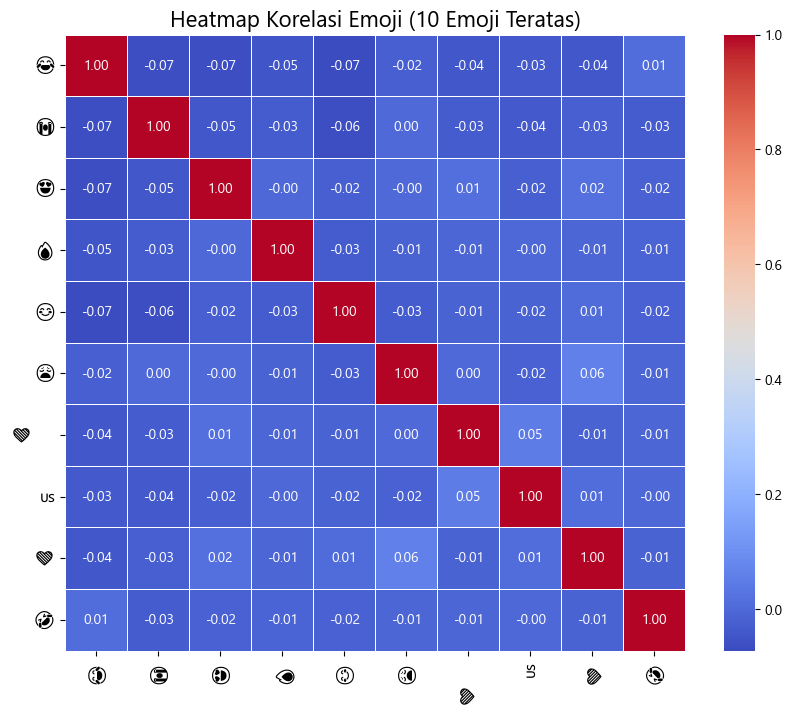

In [43]:
# Visualisasi heatmap korelasi emoji
plt.figure(figsize=(10, 8))
sns.heatmap(
    emoji_correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    xticklabels=top_emojis,
    yticklabels=top_emojis
)
plt.title("Heatmap Korelasi Emoji (10 Emoji Teratas)", fontsize=16)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12, rotation=0)
plt.show()

## Resampled DF (Undersampling)

In [57]:
# undersampling
# Divide data into majority and minority classes
df_majority = df_final[df_final['Label'] == 0]
df_minority = df_final[df_final['Label'] == 1]
print(df_majority.shape)
print(df_minority.shape)

(23208, 2)
(9289, 2)


In [58]:
# Get the number of minority class data and use it to undersample the majority class
# Undersampling is done by taking a random sample of the majority class data with the same number of minority class data
df_majority_undersampled = df_majority.sample(n=len(df_minority), random_state=42)

# Menggabungkan kembali data yang telah diundersampling
undersampled_df = pd.concat([df_majority_undersampled, df_minority])

# Menampilkan distribusi label setelah undersampling
label_counts = undersampled_df['Label'].value_counts()

In [59]:
undersampled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18578 entries, 116982 to 131884
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tweet   18578 non-null  object
 1   Label   18578 non-null  int32 
dtypes: int32(1), object(1)
memory usage: 362.9+ KB


In [60]:
print(undersampled_df['Label'].value_counts())

Label
0    9289
1    9289
Name: count, dtype: int64


In [61]:
# undersampled_df.to_csv('Data-Done/undersampled_dataset.csv', index=False)